This file provides analysis support to provide statistics and fiugres for the write up contained in "NFL_Overtime_model.ipynb." Table and charts are store in the assets directory to be pulled into the write up.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simulation.rules import *
from simulation.simulate import *
from config import *
import random
plt.style.use('default')


In [2]:
pbp_df = pd.read_parquet(DATA_DIR/PBP_FILE)
drive_list = pd.read_csv(DATA_DIR/DRIVE_FILE)
ko_list = pd.read_csv(DATA_DIR/KO_FILE)

In [3]:
# Provide the ruleset of each relevant overtime era (Kickoff rules and overtime rules)
def get_ruleset(season, week):
    is_playoff = week > 18
    if season >= 2025:
        return '2025'
    elif season == 2024:
        return '2024'  # dynamic kickoff, old OT rules
    elif season >= 2022 and is_playoff:
        return '2025'  # playoff OT same as 2025 rules
    elif season >= 2017:
        return '2017-2023'  # 35-yard kickoff
    elif season == 2016:
        return '2016'  # 25-yard touchback
    elif season >= 2012:
        return '2012-2015'  # FG-match era, 15-min OT
    else:
        return 'Pre 2012'  # pure sudden death

In [4]:
# Determine the results of historical overtime games
def aggregate_overtime_games(pbp: pd.DataFrame) -> pd.DataFrame:
    ot_plays = pbp[pbp['game_half'] == 'Overtime'].copy()

    results = []

    for game_id, game in ot_plays.groupby('game_id'):
        game = game.sort_values('play_id')

        first_play = game.iloc[0]
        season = first_play['season']
        week = first_play['week']
        receiving_team = first_play['posteam']

        home = first_play['home_team']
        away = first_play['away_team']
        kicking_team = away if receiving_team == home else home

        last_play = game.iloc[-1]
        home_score = last_play['total_home_score']
        away_score = last_play['total_away_score']

        if home_score > away_score:
            winner = home
        elif away_score > home_score:
            winner = away
        else:
            winner = 'TIE'

        results.append({
            'game_id': game_id,
            'season': season,
            'week': week,
            'ruleset': get_ruleset(season, week),
            'kicking_team': kicking_team,
            'receiving_team': receiving_team,
            'winner': winner,
            'kicking_team_won': winner == kicking_team,
            'receiving_team_won': winner == receiving_team,
            'tie': winner == 'TIE',
        })

    return pd.DataFrame(results).sort_values(['season', 'week']).reset_index(drop=True)

In [5]:
## Produce a summary table of results of overtime games in each ruleset era
hist_df = aggregate_overtime_games(pbp_df)
hist_ot_results = hist_df.groupby(['ruleset']).agg(
    games=('game_id', 'count'),
    receiving_pct=('receiving_team_won', 'mean'),
    kicking_pct=('kicking_team_won', 'mean'),
    tie_pct=('tie', 'mean'),
    year = ('season', 'max')
).sort_values(by = 'year').reset_index()

hist_ot_results['receiving_team_adv'] = hist_ot_results['receiving_pct']-hist_ot_results['kicking_pct']

hist_ot_results = hist_ot_results.rename(columns={
    'receiving_pct': '% Receiving Team Won',
    'kicking_pct': '% Kicking Team Won',
    'tie_pct': '% Tie',
    'receiving_team_adv': 'Receiving Team Advantage',
})[['ruleset','games', '% Receiving Team Won', '% Kicking Team Won', '% Tie', 'Receiving Team Advantage']]

hist_ot_results


,ruleset,games,% Receiving Team Won,% Kicking Team Won,% Tie,Receiving Team Advantage
0,Pre 2012,191,0.554974,0.434555,0.010471,0.120419
1,2012-2015,73,0.506849,0.438356,0.054795,0.068493
2,2016,14,0.428571,0.428571,0.142857,0.000000
3,2017-2023,108,0.537037,0.388889,0.074074,0.148148
4,2024,16,0.750000,0.187500,0.062500,0.562500
5,2025,17,0.529412,0.411765,0.058824,0.117647


In [6]:
# Merge the historical results with the simualted into one table
sim_results = pd.read_csv(OUTPUT_DIR/OT_RESULTS).rename(columns={
            'Receiving Team':'% Receiving Team Won',
            'Kicking Team':'% Kicking Team Won',
            'TIE': '% Tie'
        })

sim_results['ruleset'] = sim_results['season'].apply(lambda x: get_ruleset(x, 1))
merged = pd.merge(hist_ot_results, sim_results, on='ruleset', suffixes=[' Historical', ' Modeled'])
merged = merged.rename(columns = {
    'ruleset':'Ruleset',
    'games Historical': 'Games Historical',
    'games Modeled': 'Games Modeled','season':'Season Modeled'})
merged.to_csv(ASSET_DIR/HIST_COMPARISON, index = False)

In [7]:
merged

,Ruleset,Games Historical,% Receiving Team Won Historical,% Kicking Team Won Historical,% Tie Historical,Receiving Team Advantage Historical,Season Modeled,Games Modeled,% Receiving Team Won Modeled,% Kicking Team Won Modeled,% Tie Modeled,Receiving Team Advantage Modeled
0,Pre 2012,191,0.554974,0.434555,0.010471,0.120419,2011,10000,0.5264,0.4282,0.0454,0.0982
1,2012-2015,73,0.506849,0.438356,0.054795,0.068493,2013,10000,0.4776,0.4644,0.0580,0.0132
2,2016,14,0.428571,0.428571,0.142857,0.000000,2016,10000,0.4798,0.4637,0.0565,0.0161
3,2017-2023,108,0.537037,0.388889,0.074074,0.148148,2021,10000,0.4790,0.3837,0.1373,0.0953
4,2024,16,0.750000,0.187500,0.062500,0.562500,2024,10000,0.5270,0.3723,0.1007,0.1547
5,2025,17,0.529412,0.411765,0.058824,0.117647,2025,10000,0.4691,0.3938,0.1371,0.0753


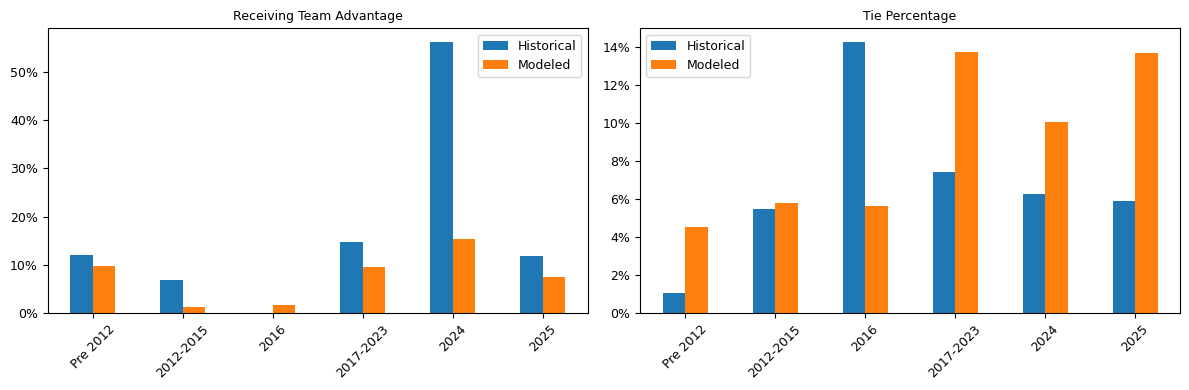

In [8]:
# Plot grouped bar charts to compare historical and modeled receiving team advantage and win rates

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fs = 9
merged.set_index('Ruleset')[['Receiving Team Advantage Historical', 'Receiving Team Advantage Modeled']].plot.bar(
    ax=axes[0]
)
axes[0].set_title('Receiving Team Advantage', fontsize = fs)

merged.set_index('Ruleset')[['% Tie Historical', '% Tie Modeled']].plot.bar(
    ax=axes[1]
)
axes[1].set_title('Tie Percentage',fontsize=fs)

for ax in axes:
    ax.legend(['Historical', 'Modeled'], fontsize=fs)
    ax.tick_params(axis = 'x', rotation = 45, labelsize = fs)
    ax.tick_params(axis='y', labelsize=fs)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xlabel('')


plt.tight_layout()
plt.savefig(ASSET_DIR/HIST_ADVANTAGE_TIES)


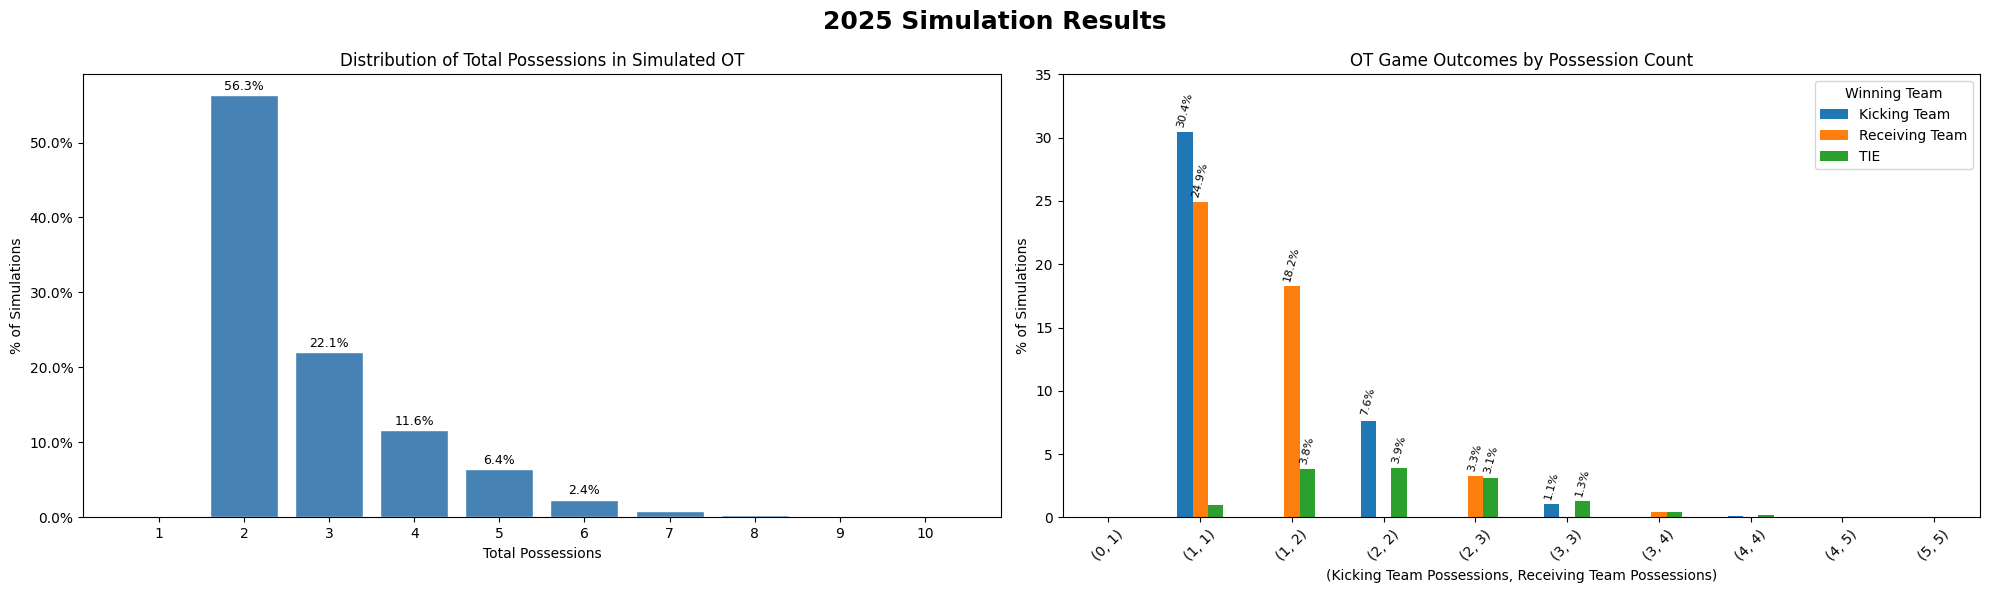

In [9]:
# Plot 2025 simulation results results. The distribution of total possessions in overtime periods and the game outcomes by possession cunt.

df2025 = pd.read_csv(output_file(2025, n=SIM_NUM))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Top: outcomes by drive count
counts = (
    df2025.groupby(['Kicking Team Possessions', 'Receiving Team Possessions', 'Winning Team'])['Winning Team']
    .count()
    .unstack('Winning Team', fill_value=0)
)
fig.suptitle('2025 Simulation Results',fontsize=18, fontweight='bold')
pcts = counts / len(df2025) * 100
pcts.plot(kind='bar', ax=ax2)
ax2.set_xlabel('(Kicking Team Possessions, Receiving Team Possessions)')
ax2.set_ylim(top=35)
ax2.set_ylabel('% of Simulations')
ax2.set_title('OT Game Outcomes by Possession Count')
ax2.legend(title='Winning Team')
ax2.tick_params(axis='x', rotation=45)

# Add labels to grouped bar chart (ax2)
for container in ax2.containers:
    for bar in container:
        height = bar.get_height()
        if height > 1:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=8,
                rotation=75
            )


# Bottom: total possession distribution
df2025['total_possessions'] = df2025['Kicking Team Possessions'] + df2025['Receiving Team Possessions']
possession_counts = df2025['total_possessions'].value_counts(normalize=True).sort_index() * 100
ax1.bar(possession_counts.index, possession_counts.values, color='steelblue', edgecolor='white')
ax1.set_xlabel('Total Possessions')
ax1.set_ylabel('% of Simulations')
ax1.set_title('Distribution of Total Possessions in Simulated OT')
ax1.set_xticks(possession_counts.index)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# Add labels to simple bar chart (ax1)
for x, y in zip(possession_counts.index, possession_counts.values):
    if y > 1:
        ax1.text(
            x, y + 0.3,
            f'{y:.1f}%',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.savefig(ASSET_DIR/POSSESSION_GRAPHS)

In [14]:
# Win rates for games that end in exactly two possessions:
df2025[df2025['total_possessions'] == 2]['Winning Team'].value_counts(normalize=True)

Winning Team
Kicking Team      0.540512
Receiving Team    0.442608
TIE               0.016880
Name: proportion, dtype: float64

In [10]:
# Winning rates for teams in overtimes that have three or more possessions
df2025[df2025['total_possessions']>=3]['Winning Team'].value_counts(normalize = True)

Winning Team
Receiving Team    0.503320
TIE               0.291962
Kicking Team      0.204717
Name: proportion, dtype: float64

In [11]:
# Fourth down conversion rate
fourth_downs = pd.read_csv(DATA_DIR/FOURTH_DOWN_FILE)
fourth_downs['fourth_down_converted'].mean()

np.float64(0.5047488896481038)

In [12]:
# Results for drives that start within field goal range.
drive_list[(drive_list['start_yardline'] <=35) & (drive_list['season'] == current_season)]['drive_result'].value_counts(normalize=True)

drive_result
TOUCHDOWN            0.460076
FIELD_GOAL           0.319392
END_GAME             0.068441
DOWNS                0.057034
INTERCEPTION         0.026616
MISSED_FG            0.026616
FUMBLE               0.022814
PUNT                 0.011407
BLOCKED_FG,_DOWNS    0.003802
END_HALF             0.003802
Name: proportion, dtype: float64

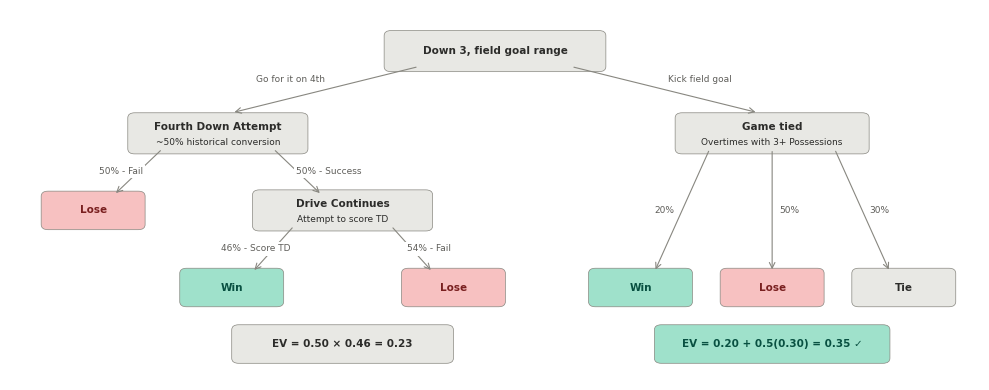

In [13]:
# Plotting a decision tree to illustrate outcomes when down 3 points in field goal range.
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 14)
ax.set_ylim(2.8, 10)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, subtext=None, color='#e8e8e4', textcolor='#2c2c2a'):
    box = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                   boxstyle="round,pad=0.1", linewidth=0.5,
                                   edgecolor='#888780', facecolor=color)
    ax.add_patch(box)
    if subtext:
        ax.text(x, y + 0.12, text, ha='center', va='center', fontsize=7.5, fontweight='bold', color=textcolor)
        ax.text(x, y - 0.18, subtext, ha='center', va='center', fontsize=6.5, color=textcolor)
    else:
        ax.text(x, y, text, ha='center', va='center', fontsize=7.5, fontweight='bold', color=textcolor)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#888780', lw=0.8))

def arrow_label(ax, x1, y1, x2, y2, label, offset_x=0, offset_y=0):
    mx = (x1 + x2) / 2 + offset_x
    my = (y1 + y2) / 2 + offset_y
    ax.text(mx, my, label, ha='center', va='center', fontsize=6.5, color='#5f5e5a',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5))

draw_box(ax, 7, 9.2, 3.0, 0.6, 'Down 3, field goal range')

draw_arrow(ax, 5.9, 8.9, 3.2, 8.0)
arrow_label(ax, 5.9, 8.9, 3.2, 8.0, 'Go for it on 4th', offset_x=-0.5, offset_y=0.2)

draw_arrow(ax, 8.1, 8.9, 10.8, 8.0)
arrow_label(ax, 8.1, 8.9, 10.8, 8.0, 'Kick field goal', offset_x=0.5, offset_y=0.2)

draw_box(ax, 3, 7.6, 2.4, 0.6, 'Fourth Down Attempt', '~50% historical conversion')
draw_arrow(ax, 2.2, 7.3, 1.5, 6.4)
arrow_label(ax, 2.2, 7.3, 1.5, 6.4, '50% - Fail', offset_x=-0.25)

draw_box(ax, 1.2, 6.1, 1.3, 0.55, 'Lose', color='#f7c1c1', textcolor='#791f1f')

draw_arrow(ax, 3.8, 7.3, 4.5, 6.4)
arrow_label(ax, 3.8, 7.3, 4.5, 6.4, '50% - Success', offset_x=0.45)

draw_box(ax, 4.8, 6.1, 2.4, 0.6, 'Drive Continues', 'Attempt to score TD')

draw_arrow(ax, 4.1, 5.8, 3.5, 4.9)
arrow_label(ax, 4.1, 5.8, 3.5, 4.9, '46% - Score TD', offset_x=-0.25)

draw_arrow(ax, 5.5, 5.8, 6.1, 4.9)
arrow_label(ax, 5.5, 5.8, 6.1, 4.9, '54% - Fail', offset_x=0.25)

draw_box(ax, 3.2, 4.6, 1.3, 0.55, 'Win', color='#9fe1cb', textcolor='#085041')
draw_box(ax, 6.4, 4.6, 1.3, 0.55, 'Lose', color='#f7c1c1', textcolor='#791f1f')

draw_box(ax, 4.8, 3.5, 3.0, 0.55, 'EV = 0.50 × 0.46 = 0.23')

draw_box(ax, 11, 7.6, 2.6, 0.6, 'Game tied', 'Overtimes with 3+ Possessions')
draw_arrow(ax, 10.1, 7.3, 9.3, 4.9)
arrow_label(ax, 10.1, 7.3, 9.3, 4.9, '20%', offset_x=-0.25)

draw_arrow(ax, 11.0, 7.3, 11.0, 4.9)
arrow_label(ax, 11.0, 7.3, 11.0, 4.9, '50%', offset_x=0.25)

draw_arrow(ax, 11.9, 7.3, 12.7, 4.9)
arrow_label(ax, 11.9, 7.3, 12.7, 4.9, '30%', offset_x=0.25)

draw_box(ax, 9.1, 4.6, 1.3, 0.55, 'Win', color='#9fe1cb', textcolor='#085041')
draw_box(ax, 11.0, 4.6, 1.3, 0.55, 'Lose', color='#f7c1c1', textcolor='#791f1f')
draw_box(ax, 12.9, 4.6, 1.3, 0.55, 'Tie', color='#e8e8e4', textcolor='#2c2c2a')

draw_box(ax, 11.0, 3.5, 3.2, 0.55, 'EV = 0.20 + 0.5(0.30) = 0.35 ✓',
         color='#9fe1cb', textcolor='#085041')

plt.tight_layout()
plt.savefig(ASSET_DIR/DECISION_TREE, dpi=120, bbox_inches='tight')
plt.show()